Statistcs of True_error compared to absolute error and signed error

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import scikit_posthocs as sp

In [66]:
df = pd.read_csv("Output_extraction/ai_grading_final.csv")

df["prompt_type"] = pd.Categorical(df["prompt_type"], 
    categories=["very_pessimistic", "pessimistic", "neutral", "confident", "very_confident"], 
    ordered=True)

required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()

df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

pd.set_option("display.max_rows", None)

We start with a simple comparison in a table

In [77]:
display(
    df.groupby("true_mistakes")[
        ["ai_error", "Absolute_error"]
    ].agg(["count", "mean", "std"])
)

ai_error                     Absolute_error                    
                 count      mean       std          count      mean       std
true_mistakes                                                                
0                  250  0.092000  0.316126            250  0.092000  0.316126
2                  250  0.316000  1.041385            250  0.364000  1.025530
4                  249  0.180723  0.764292            249  0.253012  0.743413
6                  250  0.080000  0.589057            250  0.216000  0.553688
8                  249 -0.012048  0.715508            249  0.301205  0.648850
10                 250 -0.132000  0.696070            250  0.292000  0.645292
12                 250 -0.308000  0.824533            250  0.388000  0.789906
14                 249 -0.453815  1.073356            249  0.485944  1.059140

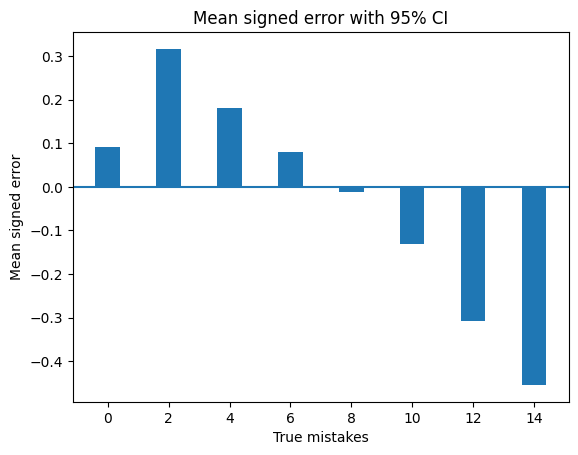

In [79]:
summary = df.groupby("true_mistakes")["ai_error"].agg(["mean", "std", "count"])


plt.bar(
    summary.index,
    summary["mean"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error")
plt.show()

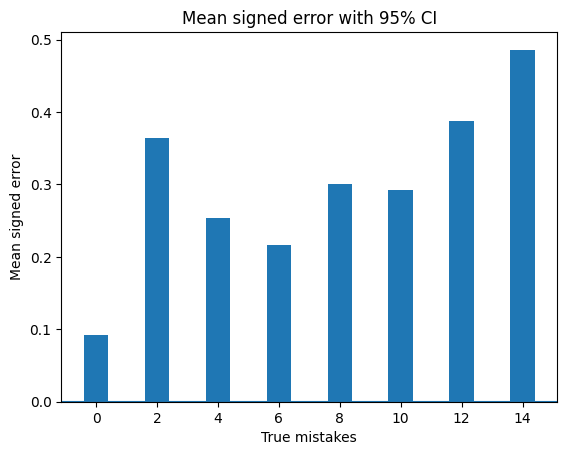

In [80]:
summary = df.groupby("true_mistakes")["Absolute_error"].agg(["mean", "std", "count"])


plt.bar(
    summary.index,
    summary["mean"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error")
plt.show()

In [70]:
# ── Kruskal-Wallis for true_mistakes ───────────────────────────────────────────

# Med ai_error (signed)
kw_signed = pg.kruskal(
    data=df,
    dv="ai_error",
    between="true_mistakes"
)
print("=== Kruskal-Wallis: ai_error (signed) ===")
print(kw_signed)

# Med Absolute_error
kw_absolute = pg.kruskal(
    data=df,
    dv="Absolute_error",
    between="true_mistakes"
)
print("\n=== Kruskal-Wallis: Absolute_error ===")
print(kw_absolute)

=== Kruskal-Wallis: ai_error (signed) ===
                Source  ddof1           H         p_unc
Kruskal  true_mistakes      7  155.159497  3.344847e-30

=== Kruskal-Wallis: Absolute_error ===
                Source  ddof1          H     p_unc
Kruskal  true_mistakes      7  37.114952  0.000004


Now using dunns becouse we see the p value is significant

In [71]:
def dunn_test(data, outcome):
    # Fjern eventuelle manglende værdier
    clean = data[["true_mistakes", outcome]].dropna()

    # Dunn-test med Holm-korrektion
    p_values = sp.posthoc_dunn(
        clean,
        val_col=outcome,
        group_col="true_mistakes",
        p_adjust="holm"
    )

    # Behold kun hver sammenligning én gang
    mask = np.triu(np.ones(p_values.shape, dtype=bool), k=1)

    results = (
        p_values
        .where(mask)
        .rename_axis(index="A", columns="B")
        .stack()
        .reset_index(name="p_corr")
        .dropna(subset=["p_corr"])
        .reset_index(drop=True)
    )

    return results

signed error

In [72]:
posthoc_signed_true = dunn_test(df, "ai_error")

display(posthoc_signed_true)
display(posthoc_signed_true[posthoc_signed_true["p_corr"] < 0.05])

,A,B,p_corr
0,0,2,1.000000e+00
1,0,4,1.000000e+00
2,0,6,1.000000e+00
3,0,8,2.607365e-02
4,0,10,1.167494e-03
5,0,12,3.026299e-10
6,0,14,7.280431e-13
7,2,4,1.000000e+00
8,2,6,1.930577e-01
9,2,8,1.992238e-04


,A,B,p_corr
3,0,8,2.607365e-02
4,0,10,1.167494e-03
5,0,12,3.026299e-10
6,0,14,7.280431e-13
9,2,8,1.992238e-04
10,2,10,2.349597e-06
11,2,12,1.510070e-14
12,2,14,1.173451e-17
14,4,8,1.082004e-02
15,4,10,3.765317e-04


Absolute error

In [73]:
posthoc_absolute_true = dunn_test(df, "Absolute_error")

print("\n=== Dunn's post-hoc test: absolute error ===")
display(posthoc_absolute_true)
display(posthoc_absolute_true[posthoc_absolute_true["p_corr"] < 0.05])


=== Dunn's post-hoc test: absolute error ===


,A,B,p_corr
0,0,2,0.083561
1,0,4,0.357491
2,0,6,0.297195
3,0,8,0.000832
4,0,10,0.002404
5,0,12,0.000026
6,0,14,0.000041
7,2,4,1.000000
8,2,6,1.000000
9,2,8,1.000000


,A,B,p_corr
3,0,8,0.000832
4,0,10,0.002404
5,0,12,0.000026
6,0,14,0.000041
